# Calculate titers

In [9]:
import os
import warnings

import math
import numpy as np 

from IPython.display import display, HTML
import matplotlib.pyplot as plt

from neutcurve.colorschemes import CBMARKERS, CBPALETTE
from mizani.formatters import scientific_format

import pandas as pd
from plotnine import *
import altair as alt

import yaml

In [2]:
warnings.simplefilter('ignore')

Read config


In [20]:
titers = pd.read_csv('data/virus_titer_RLU.csv')

titers = (titers
          .assign(RLUperuL=lambda x: x['RLU_per_well'] / x['uL_virus']
                 )
         )

display(HTML(titers.head().to_html(index=False)))

replicate,virus,dilution,uL_virus,RLU_per_well,cells,oseltamivir,RLUperuL
rep1,H5N1_Widgeon_2021,0.50000,25.0000,5198000,293T,no,207920.0
rep1,H5N1_Widgeon_2021,0.25000,12.5000,4400000,293T,no,352000.0
rep1,H5N1_Widgeon_2021,0.12500,6.2500,3041000,293T,no,486560.0
rep1,H5N1_Widgeon_2021,0.06250,3.1250,2168000,293T,no,693760.0
rep1,H5N1_Widgeon_2021,0.03125,1.5625,1228000,293T,no,785920.0


In [21]:
ncol=min(8, titers['virus'].nunique())
nrow=math.ceil(titers['virus'].nunique() / ncol)

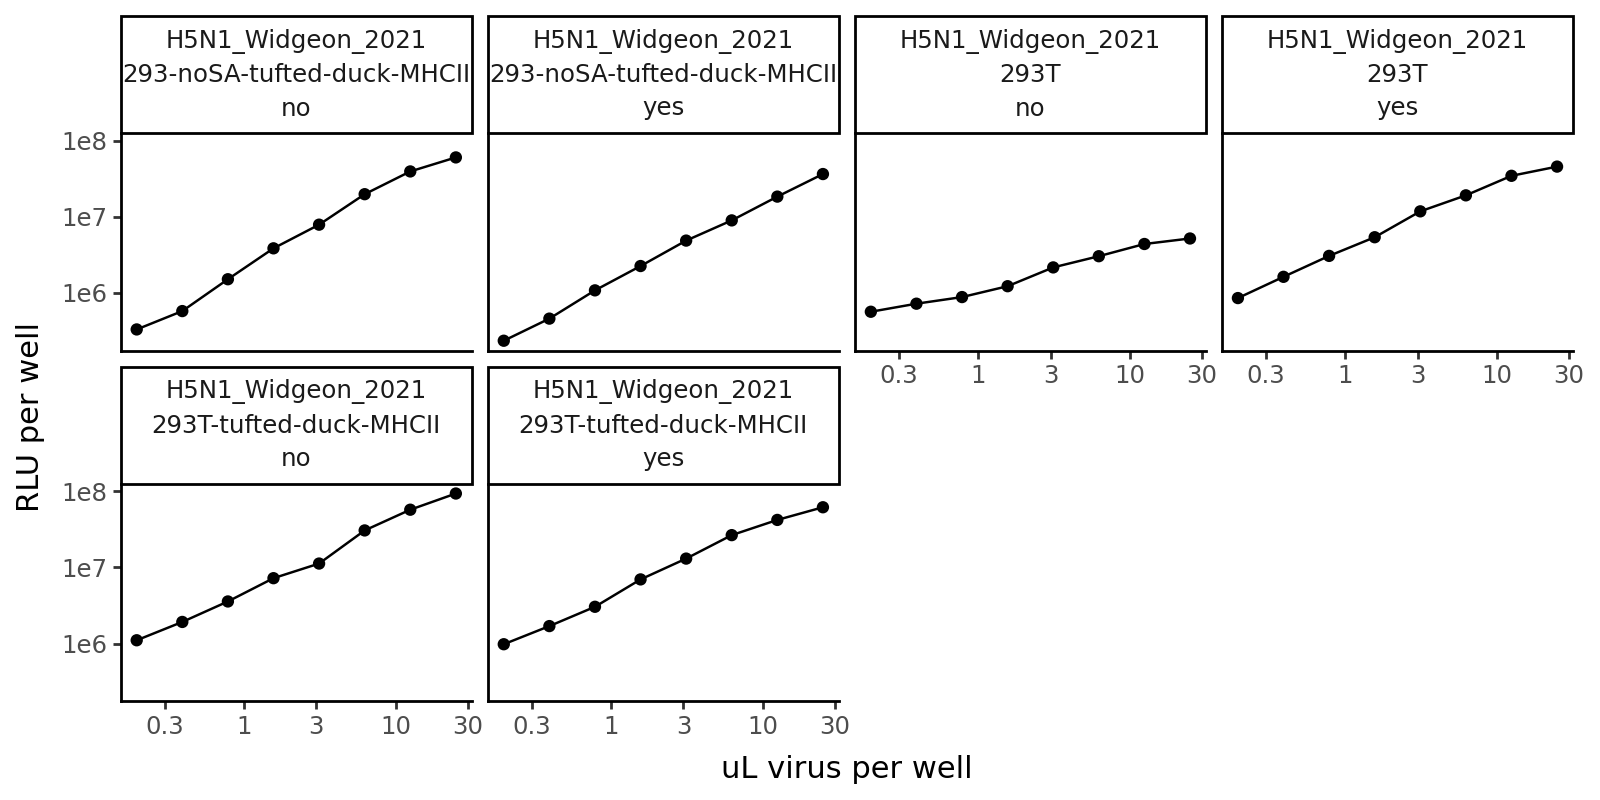

In [22]:
p = (ggplot(titers.dropna()
            ) +
     aes('uL_virus', 'RLU_per_well') +
     geom_point(size=1.5) +
     geom_line() +
     facet_wrap('~virus+cells+oseltamivir', ncol=4) +
     scale_y_log10(name='RLU per well') +
     scale_x_log10(name='uL virus per well') +
     theme_classic() +
     theme(axis_text_x=element_text(),
           figure_size=(8,4),
           )
     )

p

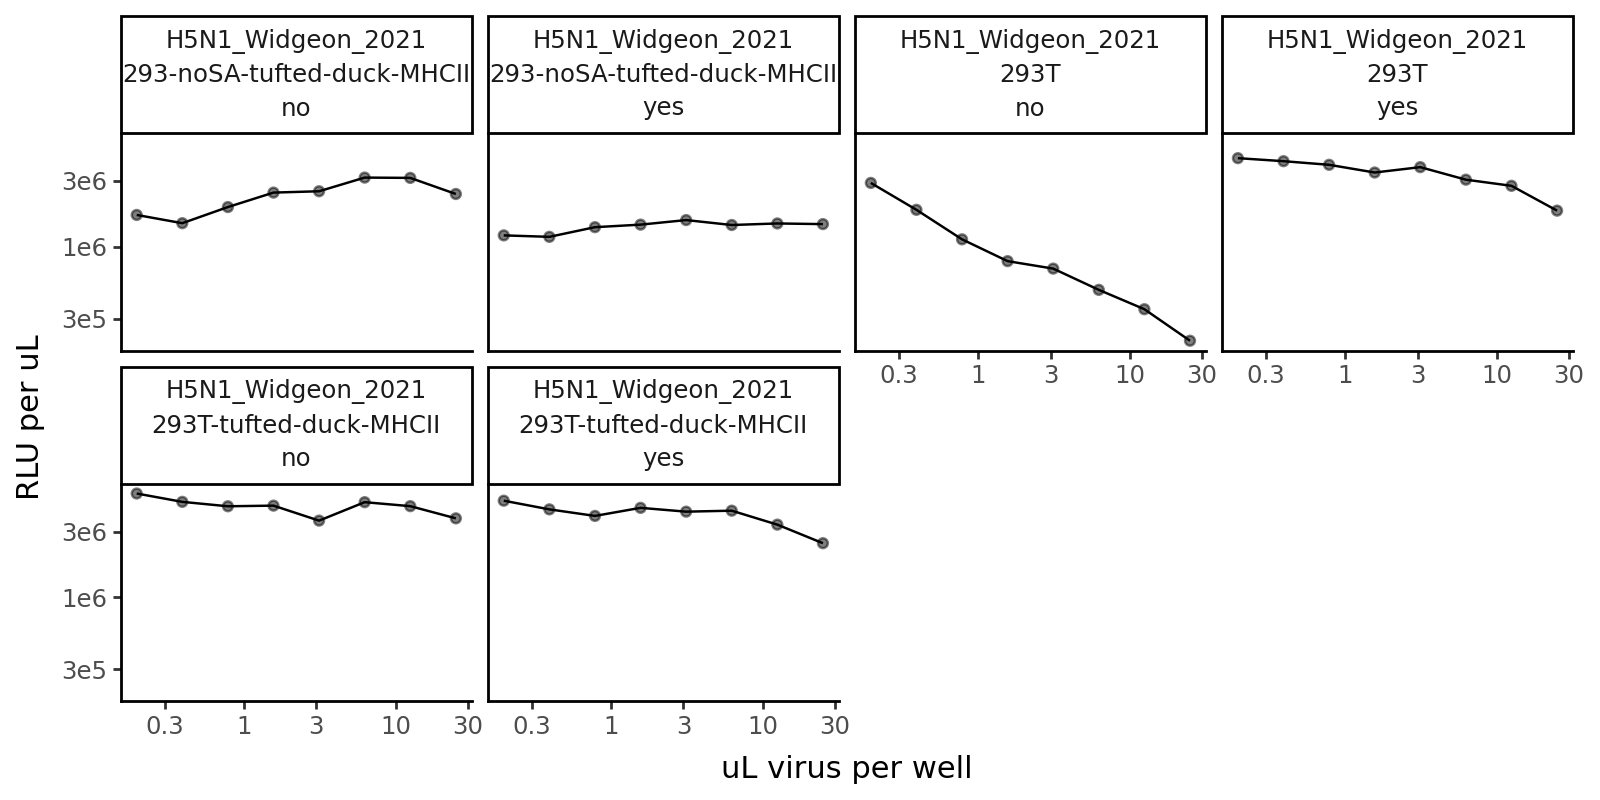

In [23]:
p = (ggplot(titers.dropna()
            ) +
     aes('uL_virus', 'RLUperuL', group='replicate') +
     geom_point(size=1.5, alpha=0.5) +
     geom_line() +
     facet_wrap('~virus+cells+oseltamivir', ncol=4) +
     scale_y_log10(name='RLU per uL') +
     scale_x_log10(name='uL virus per well') +
     theme_classic() +
     theme(axis_text_x=element_text(),
           figure_size=(8,4),
           ) 
     )

p

Check that above plots are approximately linear 

In [24]:
average_titers = (titers
                  .dropna() # missing values for some replicates
                  .groupby(['virus', "cells", 'oseltamivir'])
                  .agg(mean_RLUperuL=pd.NamedAgg(column='RLUperuL', aggfunc=np.mean))
                  .reset_index()
                 )

display(HTML(average_titers.head().to_html(index=False)))

/tmp/ipykernel_52804/2592599287.py:4: FutureWarning: The provided callable <function mean at 0x7f4c04389ee0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.


virus,cells,oseltamivir,mean_RLUperuL
H5N1_Widgeon_2021,293-noSA-tufted-duck-MHCII,no,2358194.0
H5N1_Widgeon_2021,293-noSA-tufted-duck-MHCII,yes,1394240.0
H5N1_Widgeon_2021,293T,no,1051738.0
H5N1_Widgeon_2021,293T,yes,3424078.0
H5N1_Widgeon_2021,293T-tufted-duck-MHCII,no,4580870.0


In [25]:
p = alt.Chart(average_titers).mark_point(size=100, opacity=0.9, filled=True).encode(
    x=alt.X('cells:N', axis=alt.Axis(labelAngle=-90, title=None)),
    y=alt.Y('mean_RLUperuL:Q',
            scale=alt.Scale(type='log', domain=[1e5, 1e7]),
            axis=alt.Axis(format='.0e'),
            title='RLU per µL'),
    color=alt.Color('oseltamivir:N',
                    scale=alt.Scale(range=CBPALETTE))
).properties(
    width=200,
    height=200,
    title='pseudovirus titers'
).configure_view(
    strokeWidth=0
).configure_axis(
    grid=False
)

p

alt.Chart(...)

In [26]:
# ── Save chart as html ─────────────────────────────────────────────────────────
OUTPUT_html= './virus_titers.html'
# save as HTML
p.save(OUTPUT_html)
print(f"✓ Chart saved as HTML: {OUTPUT_html}")

✓ Chart saved as HTML: ./virus_titers.html
